##Capstone Project: Chronic Kidney Disease (CKD) Prediction


In [2]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Upload the datasets
from google.colab import files
uploaded=files.upload()

Saving Testing_CKD_dataset.csv to Testing_CKD_dataset.csv
Saving Training_CKD_dataset.csv to Training_CKD_dataset.csv


In [4]:
#Read the data sets
train=pd.read_csv('Training_CKD_dataset.csv')
test=pd.read_csv('Testing_CKD_dataset.csv')

In [5]:
train.head(3)

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No


In [6]:
test.head()

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,38,0,33,114,78,78,0,10,117,...,97,4.677411,211,203,4,5.156141,No,No,Yes,No
1,Severe CKD (Stage 4),76,0,28,166,103,92,5,84,25,...,111,9.490302,194,210,2,7.922118,No,No,No,No
2,Healthy Kidney,63,0,33,109,79,98,0,17,109,...,125,6.023745,243,138,4,6.606848,No,No,No,Yes
3,Healthy Kidney,54,0,31,107,62,109,0,10,107,...,127,5.772014,163,276,4,6.651897,No,Yes,No,Yes
4,Healthy Kidney,20,0,20,111,63,92,0,17,97,...,127,8.483288,221,264,4,6.400641,No,Yes,Yes,No


#Data Cleaning

In [7]:
#checkif the train data and the test data have similar columns
train.columns
train.shape

(21000, 36)

In [8]:
test.columns
test.shape


(4800, 36)

In [9]:
#checking for duplicates in both data sets
train.duplicated().sum()
test.duplicated().sum()

np.int64(0)

In [10]:
train["Target"].unique()

array(['Healthy Kidney', 'Severe CKD (Stage 4)', 'Mild CKD (Stage 1–2)',
       'Moderate CKD (Stage 3)', 'Kidney Failure (Stage 5)'], dtype=object)

In [11]:
#Checking for missing values
train.isnull().sum().sum()

np.int64(0)

In [12]:
test.isnull().sum().sum()

test.columns

Index(['Target', 'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR',
       'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio',
       'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium',
       'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count',
       'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume',
       'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol',
       'Triglycerides', 'Serum_Albumin', 'Total_Protein', 'Diabetes',
       'Hypertension', 'Smoking_Status', 'Family_History_Kidney'],
      dtype='object')

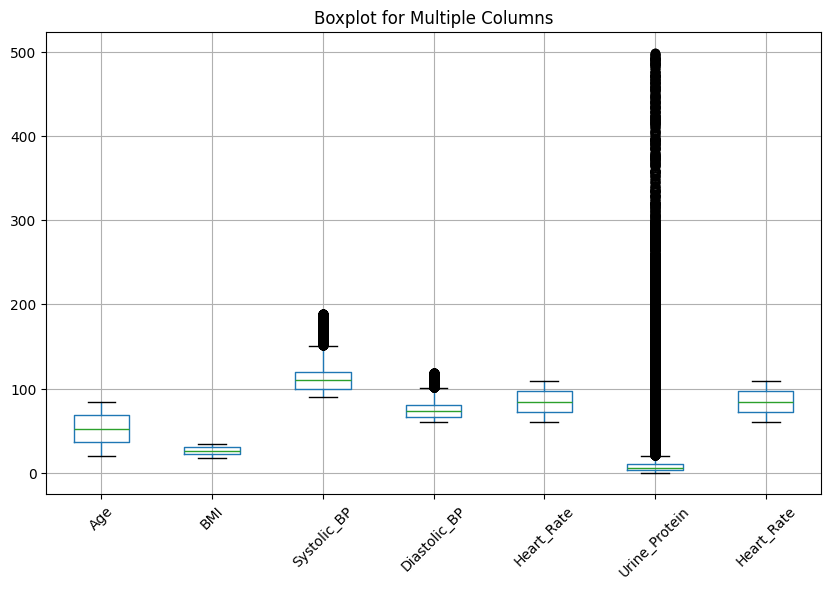

In [13]:
#checking the outliers
import matplotlib.pyplot as plt

# Select columns you want
cols = ['Age', 'BMI', 'Systolic_BP','Diastolic_BP','Heart_Rate','Urine_Protein','Heart_Rate']

train[cols].boxplot(figsize=(10,6))
plt.title("Boxplot for Multiple Columns")
plt.xticks(rotation=45)
plt.show()

#Exploratory Data analysis (EDA)

In [14]:
train.head(2)

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No


In [15]:
#check the data typpe of the data sets
train.dtypes

,0
Target,object
Age,int64
Gender,int64
BMI,int64
Systolic_BP,int64
Diastolic_BP,int64
Heart_Rate,int64
Serum_Creatinine,int64
Blood_Urea_Nitrogen,int64
eGFR,int64


In [16]:
#train data set check data types
#realise that the data gender is an integer but it should be an object so transform it to be an object
train['Gender'] = train['Gender'].astype(str)

#again check data type
train.dtypes


,0
Target,object
Age,int64
Gender,object
BMI,int64
Systolic_BP,int64
Diastolic_BP,int64
Heart_Rate,int64
Serum_Creatinine,int64
Blood_Urea_Nitrogen,int64
eGFR,int64


In [17]:
#test data set data set
test.dtypes

#showed gender as an interger  make it a object since its a categorical variable
test['Gender'] = test['Gender'].astype(str)
test.dtypes

,0
Target,object
Age,int64
Gender,object
BMI,int64
Systolic_BP,int64
Diastolic_BP,int64
Heart_Rate,int64
Serum_Creatinine,int64
Blood_Urea_Nitrogen,int64
eGFR,int64


In [18]:
train.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,Urine_Protein,...,WBC_Count,Platelet_Count,Packed_Cell_Volume,Blood_Glucose_Random,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,...,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,51.951905,25.977571,113.497619,75.280857,84.280714,0.629571,21.682048,91.426095,59.986905,31.220524,...,7493.323000,300422.551571,42.167238,134.330524,99.473762,6.998247,214.411762,199.511571,3.598048,6.507856
std,18.796090,4.890439,19.151820,12.106952,14.387748,1.482399,20.800122,26.787045,136.148540,73.192300,...,2019.807219,86546.236256,5.496877,37.623833,17.300907,1.736593,37.451581,58.167742,0.764034,0.865395
min,20.000000,18.000000,90.000000,60.000000,60.000000,0.000000,7.000000,5.000000,0.000000,0.000000,...,4000.000000,150022.000000,20.000000,70.000000,70.000000,4.000855,150.000000,100.000000,1.000000,5.000065
25%,36.000000,22.000000,99.000000,66.000000,72.000000,0.000000,11.000000,89.000000,6.000000,3.000000,...,5738.000000,225571.000000,40.000000,102.000000,84.000000,5.509804,182.000000,149.000000,3.000000,5.757357
50%,52.000000,26.000000,110.000000,73.000000,84.000000,0.000000,15.000000,99.000000,13.000000,6.000000,...,7504.000000,300718.000000,43.000000,134.000000,99.000000,7.002234,214.000000,199.000000,4.000000,6.520847
75%,68.000000,30.000000,120.000000,80.000000,97.000000,1.000000,20.000000,109.000000,20.000000,10.000000,...,9234.000000,375397.250000,46.000000,167.000000,114.000000,8.501457,247.000000,250.000000,4.000000,7.254656
max,84.000000,34.000000,189.000000,119.000000,109.000000,9.000000,149.000000,119.000000,999.000000,499.000000,...,10999.000000,449942.000000,49.000000,199.000000,129.000000,9.999904,279.000000,299.000000,4.000000,7.999568


In [19]:
test.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,Urine_Protein,...,WBC_Count,Platelet_Count,Packed_Cell_Volume,Blood_Glucose_Random,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.0000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,...,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,52.037083,26.000833,113.263542,75.198125,84.8125,0.615833,21.627917,91.892292,58.843958,30.631458,...,7466.751667,299515.230417,42.272292,134.303542,99.475000,6.981420,214.884583,201.237917,3.606042,6.504734
std,18.794795,4.948705,19.021180,11.988556,14.3716,1.451989,20.657173,26.660083,135.997999,72.425917,...,2029.807126,85795.588383,5.498965,37.316957,17.175746,1.714337,37.241641,57.471281,0.756995,0.859411
min,20.000000,18.000000,90.000000,60.000000,60.0000,0.000000,7.000000,5.000000,0.000000,0.000000,...,4000.000000,150055.000000,20.000000,70.000000,70.000000,4.003597,150.000000,100.000000,1.000000,5.000294
25%,36.000000,22.000000,100.000000,66.000000,72.0000,0.000000,11.000000,90.000000,6.000000,3.000000,...,5699.750000,225576.750000,40.000000,102.000000,85.000000,5.483372,183.000000,152.000000,4.000000,5.746804
50%,52.000000,26.000000,109.000000,73.000000,85.0000,0.000000,15.000000,100.000000,13.000000,6.000000,...,7454.000000,298463.000000,43.000000,134.000000,100.000000,6.984384,216.000000,203.000000,4.000000,6.509841
75%,68.250000,30.000000,119.000000,79.000000,97.0000,0.000000,19.000000,110.000000,19.000000,9.000000,...,9216.750000,372825.250000,46.000000,166.000000,114.000000,8.440821,247.000000,250.000000,4.000000,7.247205
max,84.000000,34.000000,189.000000,119.000000,109.0000,9.000000,149.000000,119.000000,997.000000,497.000000,...,10999.000000,449965.000000,49.000000,199.000000,129.000000,9.999472,279.000000,299.000000,4.000000,7.999326


In [20]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  object 
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  object 
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium

In [21]:
#Check if the data sets is balanced
train['Target'].value_counts(normalize=True) * 100 #Results shows our model would rely much on predicting healthy kidneys so we must use balance

,proportion
Target,
Healthy Kidney,74.971429
Mild CKD (Stage 1–2),11.861905
Moderate CKD (Stage 3),7.090476
Severe CKD (Stage 4),4.076190
Kidney Failure (Stage 5),2.000000


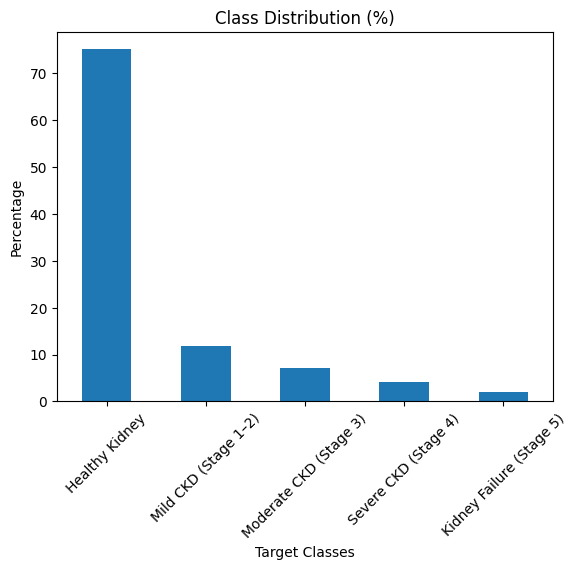

In [22]:
# Check the class distribution .class inbalance directly affect the model
class_dist = train['Target'].value_counts(normalize=True) * 100

# Plot bar chart
class_dist.plot(kind='bar')

plt.title('Class Distribution (%)')
plt.xlabel('Target Classes')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

#note dataset is inbalanced -Smotewill be applied during preprocessing

In [23]:
#Check data shape
train.shape

test.shape

(4800, 36)

In [24]:
#check if columns are similar
train.columns

Index(['Target', 'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR',
       'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio',
       'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium',
       'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count',
       'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume',
       'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol',
       'Triglycerides', 'Serum_Albumin', 'Total_Protein', 'Diabetes',
       'Hypertension', 'Smoking_Status', 'Family_History_Kidney'],
      dtype='object')

In [25]:
test.columns

Index(['Target', 'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR',
       'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio',
       'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium',
       'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count',
       'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume',
       'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol',
       'Triglycerides', 'Serum_Albumin', 'Total_Protein', 'Diabetes',
       'Hypertension', 'Smoking_Status', 'Family_History_Kidney'],
      dtype='object')

In [26]:
## check the  columns in the train data not in the test data

# Columns in train but not in test
missing_in_test = set(train.columns) - set(test.columns)
print("Columns in train but NOT in test:", missing_in_test)

# Columns in test but not in train
missing_in_train = set(test.columns) - set(train.columns)
print("Columns in test but NOT in train:", missing_in_train)


Columns in train but NOT in test: set()
Columns in test but NOT in train: set()


In [27]:
#we drop these columns because they cannot be used in our model anyway

missing_in_test=['MAP', 'pulse_pressure', 'bun_creatinine_ratio']

#train = train.drop(columns=missing_in_test)   ## note if you keep on running this shows an error coz the columns already drpped and cant be seen



In [28]:
#check if they have left
test.shape

(4800, 36)

Correlation analysis

In [29]:
# Compute correlation matrix
corr_matrix = train.select_dtypes(include='number').corr()

# Extract highly correlated pairs
#The code identifies pairs of variables in a correlation matrix (corr_matrix)
#that have a high correlation (greater than 0.8 or less than -0.8).
#It also ensures that each pair is recorded only once, avoiding duplicates such as (A, B) and (B, A)'''


seen = set()
high_corr = []

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        pair = tuple(sorted([col, row]))
        if col != row and abs(corr_matrix.loc[row, col]) > 0.8 and pair not in seen:
            seen.add(pair)
            high_corr.append({
                'Variable 1': row,
                'Variable 2': col,
                'Correlation': round(corr_matrix.loc[row, col], 2)
            })

# Create and display table
high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', ascending=False)
print(high_corr_df.to_string(index=False))




              Variable 1               Variable 2  Correlation
           Urine_Protein         Serum_Creatinine         0.96
           Urine_Albumin         Serum_Creatinine         0.96
     Blood_Urea_Nitrogen         Serum_Creatinine         0.96
           Urine_Protein            Urine_Albumin         0.96
Albumin_Creatinine_Ratio            Urine_Albumin         0.95
Albumin_Creatinine_Ratio         Serum_Creatinine         0.95
Albumin_Creatinine_Ratio            Urine_Protein         0.95
           Urine_Albumin      Blood_Urea_Nitrogen         0.94
           Urine_Protein      Blood_Urea_Nitrogen         0.94
           Serum_Albumin                     eGFR         0.94
Albumin_Creatinine_Ratio      Blood_Urea_Nitrogen         0.93
           Serum_Albumin               Hemoglobin         0.88
        Serum_Creatinine              Systolic_BP         0.86
              Phosphorus         Serum_Creatinine         0.86
     Blood_Urea_Nitrogen              Systolic_BP      

In [30]:
corr_to_drop=['Blood_Urea_Nitrogen', 'Urine_Protein',
              'Albumin_Creatinine_Ratio', 'Diastolic_BP', 'Packed_Cell_Volume', 'Fasting_Glucose', 'HbA1c']

train.shape

test.shape


#train.drop(columns=corr_to_drop, inplace=True)

train.shape

(21000, 36)

In [31]:
#test data
#test.drop(columns=corr_to_drop, inplace=True)

test.shape

(4800, 36)

In [32]:
#using the anova to check the relationship of numerical variables with the target
from scipy.stats import f_oneway

results = []

num_cols = train.select_dtypes(include='number').columns.tolist()

for col in num_cols:
    groups = [train[train['Target'] == cls][col].dropna() for cls in train['Target'].unique()]
    f_stat, p_value = f_oneway(*groups)

    results.append([col, f_stat, p_value])

results_df = pd.DataFrame(results, columns=['Feature', 'F_stat', 'p_value'])
results_df.sort_values(by='F_stat', ascending=False)

print(results_df)

                     Feature        F_stat   p_value
0                        Age  1.416905e+00  0.225425
1                        BMI  1.262000e+00  0.282445
2                Systolic_BP  2.537541e+04  0.000000
3               Diastolic_BP  2.286152e+04  0.000000
4                 Heart_Rate  1.119238e+00  0.345321
5           Serum_Creatinine  2.148783e+05  0.000000
6        Blood_Urea_Nitrogen  8.369258e+04  0.000000
7                       eGFR  4.760835e+04  0.000000
8              Urine_Albumin  1.089557e+05  0.000000
9              Urine_Protein  1.206395e+05  0.000000
10  Albumin_Creatinine_Ratio  9.746130e+04  0.000000
11    Urine_Specific_Gravity  1.289623e+00  0.271456
12                    Sodium  3.514765e-01  0.843164
13                 Potassium  8.631293e+03  0.000000
14                   Calcium  1.759505e+00  0.133937
15                Phosphorus  1.943263e+04  0.000000
16                  Chloride  3.520859e-01  0.842740
17               Bicarbonate  1.227107e+04  0.

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [33]:
# Extract features with p-value less than 0.05....remember thhis are numeicals aonly
significant_features = results_df[results_df['p_value'] < 0.05]['Feature'].tolist()

print("Significant Features (p < 0.05):")
print(significant_features)

Significant Features (p < 0.05):
['Systolic_BP', 'Diastolic_BP', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR', 'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio', 'Potassium', 'Phosphorus', 'Bicarbonate', 'Hemoglobin', 'Packed_Cell_Volume', 'Serum_Albumin']


In [34]:
#to see categorical columns
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(cat_cols)


['Target', 'Gender', 'Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']


In [35]:
#To check if the correlation of categorical variables with the target usng chi square

from scipy.stats import chi2_contingency

target = train['Target']

# Select categorical columns
cat_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove the target from the list
cat_cols = [col for col in cat_cols if col != target.name]

results = []

for col in cat_cols:
    contingency_table = pd.crosstab(train[col], target)

    # Perform Chi-Square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    results.append({
        'Feature': col,
        'Chi2_stat': chi2,
        'p_value': p_value,
        'Degrees_of_Freedom': dof
    })

# Create results DataFrame
chi2_results_df = pd.DataFrame(results).sort_values(by='p_value')

print(chi2_results_df)

                 Feature  Chi2_stat   p_value  Degrees_of_Freedom
4  Family_History_Kidney  10.050842  0.039580                   4
3         Smoking_Status   7.516144  0.111000                   4
0                 Gender   4.006409  0.405139                   4
2           Hypertension   3.040017  0.551151                   4
1               Diabetes   2.026282  0.730925                   4


Taking The most most signifinance variables in our model

In [36]:
Most_significant_features_train_adTarget =train[['Target','Family_History_Kidney','Systolic_BP', 'Serum_Creatinine', 'eGFR',
                                  'Urine_Albumin', 'Potassium', 'Phosphorus', 'Bicarbonate', 'Hemoglobin', 'Serum_Albumin']]

print(Most_significant_features_train_adTarget.head())

                 Target Family_History_Kidney  Systolic_BP  Serum_Creatinine  \
0        Healthy Kidney                   Yes           97                 0   
1  Severe CKD (Stage 4)                    No          165                 5   
2        Healthy Kidney                    No          116                 0   
3        Healthy Kidney                   Yes           93                 0   
4        Healthy Kidney                    No          111                 0   

   eGFR  Urine_Albumin  Potassium  Phosphorus  Bicarbonate  Hemoglobin  \
0    95              6          3           3           23          15   
1    28            318          5           6           18           9   
2   100              1          4           2           25          16   
3   101             11          3           3           27          13   
4   102              9          4           2           27          13   

   Serum_Albumin  
0              4  
1              2  
2              4 

In [37]:
Most_significant_features_train_adTarget.shape

(21000, 11)

In [38]:
#with the test data

Most_significant_features_adTarget_test =test[['Target','Family_History_Kidney','Systolic_BP', 'Serum_Creatinine', 'eGFR',
                                  'Urine_Albumin', 'Potassium', 'Phosphorus', 'Bicarbonate', 'Hemoglobin', 'Serum_Albumin']]

print(Most_significant_features_adTarget_test.head())

                 Target Family_History_Kidney  Systolic_BP  Serum_Creatinine  \
0        Healthy Kidney                    No          114                 0   
1  Severe CKD (Stage 4)                    No          166                 5   
2        Healthy Kidney                   Yes          109                 0   
3        Healthy Kidney                   Yes          107                 0   
4        Healthy Kidney                    No          111                 0   

   eGFR  Urine_Albumin  Potassium  Phosphorus  Bicarbonate  Hemoglobin  \
0   117             12          4           2           25          13   
1    25            409          6           5           16           7   
2   109             19          3           2           26          15   
3   107              2          4           2           23          13   
4    97              5          4           2           22          14   

   Serum_Albumin  
0              4  
1              2  
2              4 

In [39]:
Most_significant_features_adTarget_test.shape

(4800, 11)

#Feature engineering

In [40]:
Most_significant_features_train_adTarget.columns

Index(['Target', 'Family_History_Kidney', 'Systolic_BP', 'Serum_Creatinine',
       'eGFR', 'Urine_Albumin', 'Potassium', 'Phosphorus', 'Bicarbonate',
       'Hemoglobin', 'Serum_Albumin'],
      dtype='object')

In [41]:
# Combine this 3 becaues CKD affect them together not individually
Most_significant_features_train_adTarget['metabolic_imbalance'] = (
    abs(Most_significant_features_train_adTarget['Potassium'] - 4.0) +
    abs(Most_significant_features_train_adTarget['Bicarbonate'] - 24) +
    abs(Most_significant_features_train_adTarget['Phosphorus'] - 3.5)
)
Most_significant_features_train_adTarget.columns

/tmp/ipykernel_6503/4072864487.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Most_significant_features_train_adTarget['metabolic_imbalance'] = (


Index(['Target', 'Family_History_Kidney', 'Systolic_BP', 'Serum_Creatinine',
       'eGFR', 'Urine_Albumin', 'Potassium', 'Phosphorus', 'Bicarbonate',
       'Hemoglobin', 'Serum_Albumin', 'metabolic_imbalance'],
      dtype='object')

In [42]:
#Anaemia +kidney damage interaction feature ckd ofthen causes anemia (low haemogloobin )due oto reduced erythreetoin
Most_significant_features_train_adTarget['kidney_anemia_index'] = Most_significant_features_train_adTarget['Serum_Creatinine'] / (Most_significant_features_train_adTarget['Hemoglobin'] + 1)

/tmp/ipykernel_6503/2223718376.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Most_significant_features_train_adTarget['kidney_anemia_index'] = Most_significant_features_train_adTarget['Serum_Creatinine'] / (Most_significant_features_train_adTarget['Hemoglobin'] + 1)


In [43]:
#Check if the 2 variables have been successfully added
Most_significant_features_train_adTarget.columns


Most_significant_features_train_adTarget.shape

(21000, 13)

In [44]:
#similar to the test data
# Combine this 3 becaues CKD affect them together not individually
Most_significant_features_adTarget_test['metabolic_imbalance'] = (
    abs(Most_significant_features_adTarget_test['Potassium'] - 4.0) +
    abs(Most_significant_features_adTarget_test['Bicarbonate'] - 24) +
    abs(Most_significant_features_adTarget_test['Phosphorus'] - 3.5)
)
Most_significant_features_adTarget_test.columns



/tmp/ipykernel_6503/1479720790.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Most_significant_features_adTarget_test['metabolic_imbalance'] = (


Index(['Target', 'Family_History_Kidney', 'Systolic_BP', 'Serum_Creatinine',
       'eGFR', 'Urine_Albumin', 'Potassium', 'Phosphorus', 'Bicarbonate',
       'Hemoglobin', 'Serum_Albumin', 'metabolic_imbalance'],
      dtype='object')

In [45]:
#Anaemia +kidney damage interaction feature ckd ofthen causes anemia (low haemogloobin )due oto reduced erythreetoin
Most_significant_features_adTarget_test['kidney_anemia_index'] = Most_significant_features_adTarget_test['Serum_Creatinine'] / (Most_significant_features_adTarget_test['Hemoglobin'] + 1)

/tmp/ipykernel_6503/2658541708.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Most_significant_features_adTarget_test['kidney_anemia_index'] = Most_significant_features_adTarget_test['Serum_Creatinine'] / (Most_significant_features_adTarget_test['Hemoglobin'] + 1)


In [46]:
#check if th e2 columns have been successfully added
Most_significant_features_adTarget_test.shape

(4800, 13)

Data to use in training and testing


In [47]:
# Do away with the combined columns in train data

train_data=Most_significant_features_train_adTarget.drop(columns=['Potassium','Phosphorus','Bicarbonate','Hemoglobin','Serum_Creatinine'])
train_data.shape

(21000, 8)

In [48]:
# Do away with the combined columns in test data

test_data=Most_significant_features_adTarget_test.drop(columns=['Potassium','Phosphorus','Bicarbonate','Hemoglobin','Serum_Creatinine'])
test_data.shape

(4800, 8)

In [49]:
train_data.head(2)

,Target,Family_History_Kidney,Systolic_BP,eGFR,Urine_Albumin,Serum_Albumin,metabolic_imbalance,kidney_anemia_index
0,Healthy Kidney,Yes,97,95,6,4,2.5,0.0
1,Severe CKD (Stage 4),No,165,28,318,2,9.5,0.5


In [50]:
train_data['Family_History_Kidney'].unique()

array(['Yes', 'No'], dtype=object)

In [51]:
test_data['Family_History_Kidney'].unique()

array(['No', 'Yes'], dtype=object)

##Comparing the models

1.Prepare the variables for training


In [52]:
#create copies of data sets and split the data
train_data_copy=train_data.copy()
test_data_copy=test_data.copy()

X_train = train_data_copy.drop('Target', axis=1)
y_train = train_data_copy['Target']

X_test = test_data_copy.drop('Target', axis=1)
y_test = test_data_copy['Target']


In [53]:
X_test['Family_History_Kidney'].unique()

array(['No', 'Yes'], dtype=object)

In [54]:
# Clean the column
X_train['Family_History_Kidney'] = (
    X_train['Family_History_Kidney']
    .astype(str)
    .str.strip()
    .str.capitalize()
)

X_test['Family_History_Kidney'] = (
    X_test['Family_History_Kidney']
    .astype(str)
    .str.strip()
    .str.capitalize()
)

X_test['Family_History_Kidney'].unique()

array(['No', 'Yes'], dtype=object)

In [55]:
#Label encode the y variabale
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# label encode Define the mapping for label encoding
mapping = {'No': 0, 'Yes': 1}

# Apply the mapping to both training and testing datasets
X_train['Family_History_Kidney'] = X_train['Family_History_Kidney'].map(mapping)
X_test['Family_History_Kidney'] = X_test['Family_History_Kidney'].map(mapping)

X_train["Family_History_Kidney"].unique()

array([1, 0])

In [56]:
#Standardize Numerical Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Identify numerical columns (exclude the encoded categorical column)
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Remove 'family_status' if it appears in the list
numerical_cols = numerical_cols.drop('Family_History_Kidney')


# Fit the scaler on the training data and transform
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Use the same scaler to transform the test data
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_test.head()

,Family_History_Kidney,Systolic_BP,eGFR,Urine_Albumin,Serum_Albumin,metabolic_imbalance,kidney_anemia_index
0,0,0.026232,0.954734,-0.352468,0.526105,-0.486189,-0.35773
1,0,2.741443,-2.479843,2.563534,-2.091642,2.736997,2.93256
2,1,-0.234846,0.656075,-0.301053,0.526105,0.230074,-0.35773
3,1,-0.339277,0.581411,-0.425919,0.526105,-0.486189,-0.35773
4,0,-0.130415,0.208087,-0.403884,0.526105,-0.128058,-0.35773


1.Train logistic model



In [57]:
X_train_l = X_train.copy()
X_test_l= X_test.copy()
y_train_l=y_train.copy()
y_test_l=y_test.copy()

print(X_test_l.head()
)


   Family_History_Kidney  Systolic_BP      eGFR  Urine_Albumin  Serum_Albumin  \
0                      0     0.026232  0.954734      -0.352468       0.526105   
1                      0     2.741443 -2.479843       2.563534      -2.091642   
2                      1    -0.234846  0.656075      -0.301053       0.526105   
3                      1    -0.339277  0.581411      -0.425919       0.526105   
4                      0    -0.130415  0.208087      -0.403884       0.526105   

   metabolic_imbalance  kidney_anemia_index  
0            -0.486189             -0.35773  
1             2.736997              2.93256  
2             0.230074             -0.35773  
3            -0.486189             -0.35773  
4            -0.128058             -0.35773  


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


# 1. Model with imbalance handling
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# 2. Train
model.fit(X_train_l, y_train_l)

# 3. Predict
y_pred = model.predict(X_test_l)
y_proba = model.predict_proba(X_test_l)

# 4. Metrics
print("Accuracy:", accuracy_score(y_test_l, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_l, y_pred))
print("\nClassification Report:\n", classification_report(y_test_l, y_pred))
print("ROC-AUC Score:", roc_auc_score(
    y_test_l,
    y_proba,
    multi_class='ovr'
))


Accuracy: 1.0

Confusion Matrix:
 [[3615    0    0    0    0]
 [   0   96    0    0    0]
 [   0    0  575    0    0]
 [   0    0    0  318    0]
 [   0    0    0    0  196]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3615
           1       1.00      1.00      1.00        96
           2       1.00      1.00      1.00       575
           3       1.00      1.00      1.00       318
           4       1.00      1.00      1.00       196

    accuracy                           1.00      4800
   macro avg       1.00      1.00      1.00      4800
weighted avg       1.00      1.00      1.00      4800

ROC-AUC Score: 1.0


In [59]:
X_train_l.head()

,Family_History_Kidney,Systolic_BP,eGFR,Urine_Albumin,Serum_Albumin,metabolic_imbalance,kidney_anemia_index
0,1,-0.861433,0.133422,-0.396539,0.526105,-0.486189,-0.357730
1,0,2.689228,-2.367846,1.895130,-2.091642,2.020733,2.274502
2,0,0.130663,0.320084,-0.433264,0.526105,-0.486189,-0.357730
3,1,-1.070295,0.357417,-0.359813,0.526105,0.230074,-0.357730
4,0,-0.130415,0.394749,-0.374504,0.526105,0.230074,-0.357730


2. XGBoost model (MULTI-CLASS)

In [60]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score)

# Determine the number of classes
num_classes = len(np.unique(y_train_l))

# Initialize the XGBoost classifier
xgb_model = XGBClassifier(
    objective='multi:softprob',  # For multi-class probability output
    num_class=num_classes,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

# Train the model
xgb_model.fit(X_train_l, y_train_l)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:21:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=5, ...)

In [61]:
#make predictions
# Predicted class labels
y_pred = xgb_model.predict(X_test_l)

# Predicted probabilities for each class
y_proba = xgb_model.predict_proba(X_test)




In [62]:
#evaluate model performance
accuracy = accuracy_score(y_test_l, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test_l, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 1.0000

Confusion Matrix:
 [[3615    0    0    0    0]
 [   0   96    0    0    0]
 [   0    0  575    0    0]
 [   0    0    0  318    0]
 [   0    0    0    0  196]]


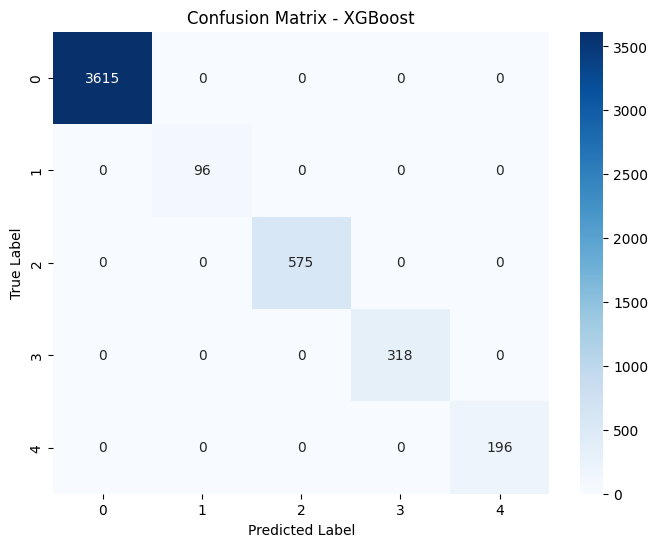

In [63]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [64]:
roc_auc = roc_auc_score(
    y_test_l,
    y_proba,
    multi_class='ovr',
    average='weighted'  # Handles class imbalance
)

print(f"ROC-AUC Score (OvR): {roc_auc:.4f}")

ROC-AUC Score (OvR): 1.0000


In [65]:
# Check feature names for potential leakage
print(X_train.columns)

# Examine feature importance from XGBoost
import pandas as pd
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

Index(['Family_History_Kidney', 'Systolic_BP', 'eGFR', 'Urine_Albumin',
       'Serum_Albumin', 'metabolic_imbalance', 'kidney_anemia_index'],
      dtype='object')
eGFR                     0.292630
Systolic_BP              0.285689
Serum_Albumin            0.228922
kidney_anemia_index      0.192398
Urine_Albumin            0.000200
metabolic_imbalance      0.000161
Family_History_Kidney    0.000000
dtype: float32


3. Neural Networks

In [ ]:
print()

In [67]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

# ---------------------------------------------------
# 1. Compute Class Weights (to handle class imbalance)
# ---------------------------------------------------
# y_train is already integer labels, no need for argmax
y_train_labels = y_train

class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_values)
}

# ---------------------------------------------------
# 2. Build the Neural Network Model
# ---------------------------------------------------
# num_classes needs to be derived from the unique values in y_train
num_classes = len(np.unique(y_train))

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Use X_train, not X_train_scaled
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')  # Output layer for multi-class classification
])

# ---------------------------------------------------
# 3. Compile the Model
# ---------------------------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

# ---------------------------------------------------
# 4. Define Callbacks
# ---------------------------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

# ---------------------------------------------------
# 5. Train the Model
# ---------------------------------------------------
history = model.fit(
    X_train, # Use X_train, not X_train_scaled
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ---------------------------------------------------
# 6. Evaluate the Model on the Test Set
# ---------------------------------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0) # Use X_test, not X_test_scaled
print(f"Test Accuracy: {test_accuracy:.4f}")

# ---------------------------------------------------
# 7. Generate Predictions
# ---------------------------------------------------
y_proba = model.predict(X_test) # Use X_test, not X_test_scaled
y_pred = np.argmax(y_proba, axis=1)
y_true = y_test # y_test is already integer labels

# ---------------------------------------------------
# 8. Compute Evaluation Metrics
# ---------------------------------------------------
print("\nAccuracy:", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

print("\nClassification Report:\n",
      classification_report(
          y_true,
          y_pred,
          target_names=le.classes_ if 'le' in globals() else None # Use 'le' from previous cell
      ))

# Multi-class ROC-AUC (One-vs-Rest)
roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr',
    average='weighted'
)
print(f"\nROC-AUC Score (OvR): {roc_auc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8054 - loss: 0.9262 - val_accuracy: 0.9955 - val_loss: 0.0950 - learning_rate: 0.0010
Epoch 2/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9552 - loss: 0.3005 - val_accuracy: 0.9998 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 3/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9748 - loss: 0.1606 - val_accuracy: 1.0000 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 4/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9806 - loss: 0.1126 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 5/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9847 - loss: 0.0896 - val_accuracy: 0.9993 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 6/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9865 - loss: 0.0798 - val_accuracy: 0.9998 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9926 - loss: 0.

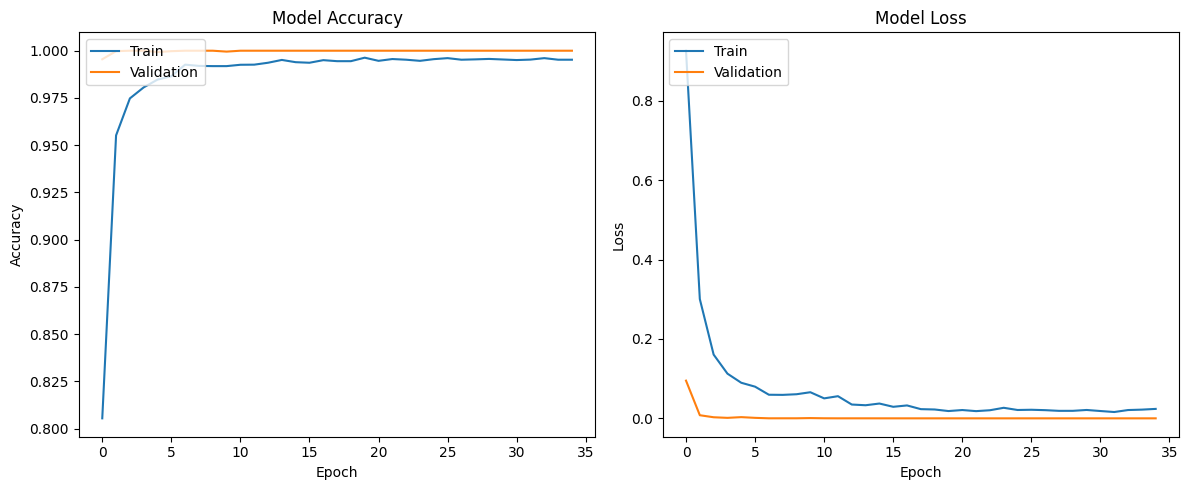

In [68]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [69]:
print(f"Unique categories in y_train: {np.unique(y_train)}")
print(f"Number of unique categories: {len(np.unique(y_train))}")
print(f"Original class names: {le.classes_}")

Unique categories in y_train: [0 1 2 3 4]
Number of unique categories: 5
Original class names: ['Healthy Kidney' 'Kidney Failure (Stage 5)' 'Mild CKD (Stage 1–2)'
 'Moderate CKD (Stage 3)' 'Severe CKD (Stage 4)']
